# Combined BCC/FCC/SC/Random 3D CNN

This notebook trains one shared 3D CNN on the three cubic lattice families plus a separate random class. The output classes are:

- `0`: BCC
- `1`: FCC
- `2`: SC
- `3`: Random / liquid-like

The source generators now write compact source labels (`0 = solid`, `1 = random`), but this notebook assigns the four combined model classes directly from the source dataset names.


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import regularizers
from keras.models import Sequential
from keras.layers import (
    Input,
    Conv3D,
    MaxPooling3D,
    GlobalAveragePooling3D,
    Dense,
    Dropout,
    BatchNormalization,
    SpatialDropout3D,
)
from keras.utils import Sequence
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix


2026-06-03 19:09:16.817126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 19:09:16.827596: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 19:09:16.831865: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
NDIM = 32
NCHANNEL = 1
NCLASS = 4
BATCH_SIZE = 48
STEPS_PER_EPOCH = 8333    # ~400k samples/epoch at batch 48
VALIDATION_STEPS = 833    # ~40k validation samples/epoch at batch 48
EPOCHS = 20
RNG_SEED = 20260430

CLASS_NAMES = ['BCC', 'FCC', 'SC', 'Random']
LATTICE_NAMES = ['bcc', 'fcc', 'scc']
LATTICE_CLASS = {'bcc': 0, 'fcc': 1, 'scc': 2}
RANDOM_CLASS = 3


## Load memory-mapped datasets

The volume arrays are opened with `mmap_mode='r'` so the notebook samples from disk instead of loading all BCC/FCC/SC/random arrays into memory at once. Source `y*.npy` files are intentionally not loaded here because combined-class labels are assigned by dataset source.


In [3]:
def split_suffix(split):
    return '400k-2' if split == 'train' else '40k'


def load_phase_arrays(split):
    suffix = split_suffix(split)
    arrays = {}
    for lattice in LATTICE_NAMES:
        if split == 'train':
            x_path = f'xtrain-large-{lattice}{suffix}.npy'
        else:
            x_path = f'xvalid-large-{lattice}{suffix}.npy'
        arrays[lattice] = {
            'x': np.load(x_path, mmap_mode='r'),
        }
        print(split, lattice, arrays[lattice]['x'].shape)
    return arrays


def load_random_array(split):
    suffix = split_suffix(split)
    if split == 'train':
        x_path = f'xtrain-large-random{suffix}.npy'
    else:
        x_path = f'xvalid-large-random{suffix}.npy'
    array = {
        'x': np.load(x_path, mmap_mode='r'),
    }
    print(split, 'random', array['x'].shape)
    return array

train_arrays = load_phase_arrays('train')
valid_arrays = load_phase_arrays('valid')
train_random_array = load_random_array('train')
valid_random_array = load_random_array('valid')


train bcc (400000, 32, 32, 32, 1)
train fcc (400000, 32, 32, 32, 1)
train scc (400000, 32, 32, 32, 1)
valid bcc (40000, 32, 32, 32, 1)
valid fcc (40000, 32, 32, 32, 1)
valid scc (40000, 32, 32, 32, 1)
train random (400000, 32, 32, 32, 1)
valid random (40000, 32, 32, 32, 1)


## Dataset Density Check

The combined classifier should not be able to identify class by atom count alone. This cell checks the metadata sidecars created by the current generators and prints atom-count summaries for each split/class.


In [4]:
def metadata_path(split, name):
    suffix = split_suffix(split)
    prefix = 'train-large' if split == 'train' else 'valid-large'
    return f'metadata-{prefix}-{name}{suffix}.npz'


def load_density_metadata(split):
    rows = []
    for name in LATTICE_NAMES + ['random']:
        path = metadata_path(split, name)
        if not os.path.exists(path):
            print('missing metadata:', path)
            continue
        data = np.load(path, allow_pickle=True)
        atom_count = data['atom_count']
        rows.append((split, name, atom_count.min(), atom_count.mean(), atom_count.std(), atom_count.max()))
        print(
            split,
            name,
            'n min/mean/std/max:',
            int(atom_count.min()),
            float(atom_count.mean()),
            float(atom_count.std()),
            int(atom_count.max()),
        )
    return rows

train_density_rows = load_density_metadata('train')
valid_density_rows = load_density_metadata('valid')


train bcc n min/mean/std/max: 25 42.42604 9.919021368985955 60
train fcc n min/mean/std/max: 25 42.5121375 10.05920462467554 60
train scc n min/mean/std/max: 25 42.34556 10.054503880669598 60
train random n min/mean/std/max: 25 42.4486475 7.7396561887944175 60
valid bcc n min/mean/std/max: 25 42.446725 9.91973345278869 60
valid fcc n min/mean/std/max: 25 42.561975 10.033210308738425 60
valid scc n min/mean/std/max: 25 42.391175 10.068115867399174 60
valid random n min/mean/std/max: 25 42.4447 7.490409996121707 60


## Balanced remapping generator

Each batch is balanced across the four combined classes. For `BCC`, `FCC`, and `SC`, the generator draws from the corresponding solid-only source dataset. For `Random`, it draws from the separate random source dataset.


In [5]:
class CombinedPhaseSequence(Sequence):
    def __init__(self, arrays, random_array, batch_size=32, steps=1000, seed=12345, shuffle=True):
        self.arrays = arrays
        self.random_array = random_array
        self.batch_size = batch_size
        self.steps = steps
        self.shuffle = shuffle
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.epoch = 0
        self.solid_indices = {}
        self.random_indices = np.arange(random_array['x'].shape[0])

        for lattice, data in arrays.items():
            self.solid_indices[lattice] = np.arange(data['x'].shape[0])
            print(lattice, 'solid:', len(self.solid_indices[lattice]))
        print('random:', len(self.random_indices))

    def __len__(self):
        return self.steps

    def on_epoch_end(self):
        self.epoch += 1
        if self.shuffle:
            self.rng = np.random.default_rng(self.seed + self.epoch)

    def _rng_for_batch(self, batch_index):
        if self.shuffle:
            return self.rng
        return np.random.default_rng(self.seed + batch_index)

    def _sample_solid(self, lattice, rng):
        idx = rng.choice(self.solid_indices[lattice])
        return self.arrays[lattice]['x'][idx], LATTICE_CLASS[lattice]

    def _sample_random(self, rng):
        idx = rng.choice(self.random_indices)
        return self.random_array['x'][idx], RANDOM_CLASS

    def __getitem__(self, batch_index):
        rng = self._rng_for_batch(batch_index)
        x_batch = np.zeros((self.batch_size, NDIM, NDIM, NDIM, NCHANNEL), dtype=np.float32)
        y_batch = np.zeros((self.batch_size, NCLASS), dtype=np.float32)

        class_cycle = np.tile(np.arange(NCLASS), int(np.ceil(self.batch_size / NCLASS)))[:self.batch_size]
        if self.shuffle:
            rng.shuffle(class_cycle)
        else:
            class_cycle = np.roll(class_cycle, batch_index % NCLASS)

        for i, cls in enumerate(class_cycle):
            if cls == RANDOM_CLASS:
                x, label = self._sample_random(rng)
            else:
                lattice = LATTICE_NAMES[cls]
                x, label = self._sample_solid(lattice, rng)

            x_batch[i] = x
            y_batch[i, label] = 1.0

        return x_batch, y_batch

train_seq = CombinedPhaseSequence(
    train_arrays,
    train_random_array,
    batch_size=BATCH_SIZE,
    steps=STEPS_PER_EPOCH,
    seed=RNG_SEED,
    shuffle=True,
)
valid_seq = CombinedPhaseSequence(
    valid_arrays,
    valid_random_array,
    batch_size=BATCH_SIZE,
    steps=VALIDATION_STEPS,
    seed=RNG_SEED + 1,
    shuffle=False,
)


bcc solid: 400000
fcc solid: 400000
scc solid: 400000
random: 400000
bcc solid: 40000
fcc solid: 40000
scc solid: 40000
random: 40000


## Shared 3D CNN

This version avoids a large `Flatten -> Dense` head. `GlobalAveragePooling3D` reduces the parameter count and makes the classifier less dependent on exact voxel positions. `SpatialDropout3D` regularizes whole feature maps, which is usually a better fit for convolutional features than only dropping dense units.


In [6]:
model_combined = Sequential([
    Input(shape=(NDIM, NDIM, NDIM, NCHANNEL)),

    Conv3D(16, kernel_size=5, activation='relu', padding='same',
           use_bias=False,
           kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    MaxPooling3D(pool_size=2),

    Conv3D(32, kernel_size=3, activation='relu', padding='same',
           use_bias=False,
           kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    SpatialDropout3D(0.10),
    MaxPooling3D(pool_size=2),

    Conv3D(64, kernel_size=3, activation='relu', padding='same',
           use_bias=False,
           kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    SpatialDropout3D(0.15),
    MaxPooling3D(pool_size=2),

    Conv3D(96, kernel_size=3, activation='relu', padding='same',
           use_bias=False,
           kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),

    GlobalAveragePooling3D(),
    Dropout(0.30),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.20),
    Dense(NCLASS, activation='softmax'),
])

model_combined.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model_combined.summary()


I0000 00:00:1780513771.795743     168 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1780513771.986775     168 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1780513771.988871     168 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1780513771.991839     168 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 32, 32, 32, 16) │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 16, 16, 16, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 16, 16, 16, 32) │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 16, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout3d               │ (None, 16, 16, 16, 32) │             0 │
│ (SpatialDropout3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 8, 8, 8, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 8, 8, 8, 64)    │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 8, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout3d_1             │ (None, 8, 8, 8, 64)    │             0 │
│ (SpatialDropout3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 4, 4, 4, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 4, 4, 4, 96)    │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 4, 96)    │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,308 (954.33 KB)

 Trainable params: 243,892 (952.70 KB)

 Non-trainable params: 416 (1.62 KB)

In [7]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
    ModelCheckpoint(
        'saved-model-combined-bcc-fcc-scc-random-best.keras',
        monitor='val_loss',
        save_best_only=True,
    ),
]

history = model_combined.fit(
    train_seq,
    epochs=EPOCHS,
    validation_data=valid_seq,
    callbacks=callbacks,
)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1780513777.150360     284 service.cc:146] XLA service 0x75c2cc002250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780513777.150539     284 service.cc:154]   StreamExecutor device (0): NVIDIA RTX PRO 6000 Blackwell Workstation Edition, Compute Capability 12.0
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  28/8333 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - accuracy: 0.4824 - loss: 1.0552    

I0000 00:00:1780513780.957493     284 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8326/8333 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9746 - loss: 0.0779 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


8333/8333 ━━━━━━━━━━━━━━━━━━━━ 124s 14ms/step - accuracy: 0.9746 - loss: 0.0779 - val_accuracy: 0.9863 - val_loss: 0.0518 - learning_rate: 0.0010
Epoch 2/20
8333/8333 ━━━━━━━━━━━━━━━━━━━━ 148s 18ms/step - accuracy: 0.9988 - loss: 0.0218 - val_accuracy: 0.9908 - val_loss: 0.0505 - learning_rate: 0.0010
Epoch 3/20
8333/8333 ━━━━━━━━━━━━━━━━━━━━ 147s 18ms/step - accuracy: 0.9991 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 4/20
8333/8333 ━━━━━━━━━━━━━━━━━━━━ 144s 17ms/step - accuracy: 0.9992 - loss: 0.0168 - val_accuracy: 0.9995 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 5/20
8333/8333 ━━━━━━━━━━━━━━━━━━━━ 151s 18ms/step - accuracy: 0.9991 - loss: 0.0157 - val_accuracy: 0.9996 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 6/20
8333/8333 ━━━━━━━━━━━━━━━━━━━━ 151s 18ms/step - accuracy: 0.9994 - loss: 0.0140 - val_accuracy: 1.0000 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 7/20
8333/8333 ━━━━━━━━━━━━━━━━━━━━ 146s 18ms/step - accuracy: 

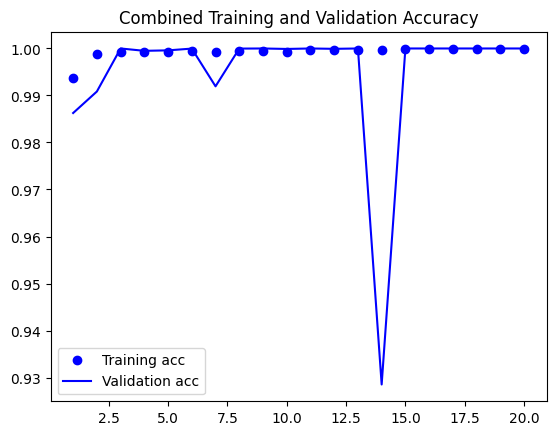

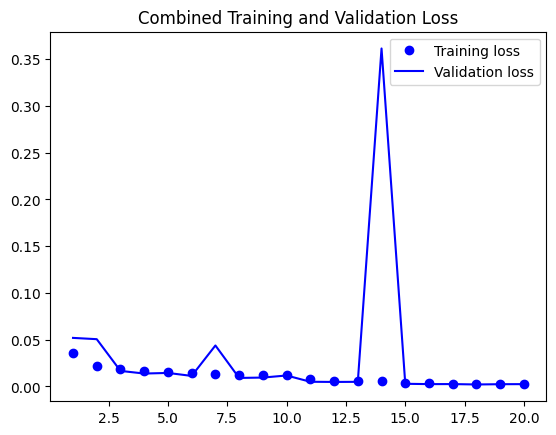

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Combined Training and Validation Accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Combined Training and Validation Loss')
plt.legend()
plt.show()


## Evaluation

This evaluates the four-class classifier and also reports solid-vs-random accuracy by aggregating the three lattice probabilities/classes into one `solid` category.


In [9]:
def collect_predictions(model, sequence, steps=200):
    y_true = []
    y_prob = []
    for i in range(steps):
        xb, yb = sequence[i]
        probs = model.predict(xb, verbose=0)
        y_true.append(yb)
        y_prob.append(probs)
    return np.concatenate(y_true), np.concatenate(y_prob)

y_true, y_prob = collect_predictions(model_combined, valid_seq, steps=500)
y_true_class = y_true.argmax(axis=1)
y_pred_class = y_prob.argmax(axis=1)

print(classification_report(y_true_class, y_pred_class, target_names=CLASS_NAMES))
print(confusion_matrix(y_true_class, y_pred_class))

true_solid = y_true_class != RANDOM_CLASS
pred_solid = y_pred_class != RANDOM_CLASS
solid_accuracy = (true_solid == pred_solid).mean()
solid_probability = y_prob[:, :RANDOM_CLASS].sum(axis=1)

print('solid-vs-random accuracy:', solid_accuracy)
print('mean P(solid) for true solid:', solid_probability[true_solid].mean())
print('mean P(solid) for true random:', solid_probability[~true_solid].mean())

if 'history' in globals():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    print('final train/val accuracy gap:', final_train_acc - final_val_acc)
    print('final val/train loss gap:', final_val_loss - final_train_loss)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


              precision    recall  f1-score   support

         BCC       1.00      1.00      1.00      6000
         FCC       1.00      1.00      1.00      6000
         SCC       1.00      1.00      1.00      6000
      Random       1.00      1.00      1.00      6000

    accuracy                           1.00     24000
   macro avg       1.00      1.00      1.00     24000
weighted avg       1.00      1.00      1.00     24000

[[6000    0    0    0]
 [   0 6000    0    0]
 [   0    0 6000    0]
 [   0    0    0 6000]]
solid-vs-random accuracy: 1.0
mean P(solid) for true solid: 1.0
mean P(solid) for true random: 1.5084281e-07
final train/val accuracy gap: -0.00017750263214111328
final val/train loss gap: -0.0006446032784879208


## Save model


In [78]:
model_combined.save('saved-model-combined-bcc-fcc-scc-random-2026-0602.keras')
# The lowest-validation-loss checkpoint is saved during training as:
# saved-model-combined-bcc-fcc-scc-random-best.keras


## Optional: Load saved combined model

Run this cell when you want to use the saved model for evaluation or vibration sweeps without retraining. The original training and saving cells above are intentionally kept unchanged.


In [21]:
import os
import keras

SAVED_COMBINED_MODEL_PATH = 'saved-model-combined-bcc-fcc-scc-random-best.keras'

if not os.path.exists(SAVED_COMBINED_MODEL_PATH):
    SAVED_COMBINED_MODEL_PATH = 'saved-model-combined-bcc-fcc-scc-random-2026-0526.keras'

model_combined = keras.models.load_model(SAVED_COMBINED_MODEL_PATH)
print('Loaded model:', SAVED_COMBINED_MODEL_PATH)
model_combined.summary()


Loaded model: saved-model-combined-bcc-fcc-scc-random-best.keras


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_4 (Conv3D)               │ (None, 32, 32, 32, 16) │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 16, 16, 16, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 16, 16, 16, 32) │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 16, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout3d_2             │ (None, 16, 16, 16, 32) │             0 │
│ (SpatialDropout3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 8, 8, 8, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_6 (Conv3D)               │ (None, 8, 8, 8, 64)    │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 8, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout3d_3             │ (None, 8, 8, 8, 64)    │             0 │
│ (SpatialDropout3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 4, 4, 4, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 4, 4, 4, 96)    │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 4, 96)    │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d_1      │ (None, 96)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 732,094 (2.79 MB)

 Trainable params: 243,892 (952.70 KB)

 Non-trainable params: 416 (1.62 KB)

 Optimizer params: 487,786 (1.86 MB)

## Helper for Lindemann sweeps with the combined model

For a BCC/FCC/SC displacement sweep, use the lattice-specific class probability and the aggregate solid probability:

- BCC sweep: `P(BCC)` and `P(solid)`
- FCC sweep: `P(FCC)` and `P(solid)`
- SC sweep: `P(SC)` and `P(solid)`

This avoids asking only "solid or random?" and also tells you whether the distorted lattice is still recognized as the same crystal family.


In [11]:
def combined_model_phase_metrics(probabilities, lattice_name):
    lattice_idx = LATTICE_CLASS[lattice_name.lower()]
    lattice_probability = probabilities[:, lattice_idx]
    solid_probability = probabilities[:, :RANDOM_CLASS].sum(axis=1)
    predicted_class = probabilities.argmax(axis=1)
    same_lattice = predicted_class == lattice_idx
    solid = predicted_class != RANDOM_CLASS
    entropy = -np.sum(np.clip(probabilities, 1e-8, 1.0) * np.log(np.clip(probabilities, 1e-8, 1.0)), axis=1)
    return {
        'lattice_probability_mean': float(lattice_probability.mean()),
        'solid_probability_mean': float(solid_probability.mean()),
        'same_lattice_accuracy': float(same_lattice.mean()),
        'solid_accuracy': float(solid.mean()),
        'entropy_mean': float(entropy.mean()),
    }


In [80]:
%run combined-vibration-testing.py --lattices scc fcc bcc --nval 2000 --factors 0.0 0.02 0.04 0.06 0.08 0.10 0.12 0.14 0.16 0.18 0.20 0.22 0.24 0.26 0.28 0.30 0.32 0.34 0.36 0.38 0.40 0.42 0.44 0.46 0.48 0.50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


scc factor 0.0 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9999998807907104 P_solid 1.0 measured_L 0.0 nn_cv 1.0871696787262408e-07 time 38.56086730957031
scc factor 0.019999999552965164 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9999998807907104 P_solid 0.9999999403953552 measured_L 0.019957557320594788 nn_cv 0.009779185056686401 time 35.96124577522278
scc factor 0.03999999910593033 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9999998807907104 P_solid 0.9999998807907104 measured_L 0.039900679141283035 nn_cv 0.020076721906661987 time 35.855774879455566
scc factor 0.05999999865889549 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9999997615814209 P_solid 0.9999998211860657 measured_L 0.06008352339267731 nn_cv 0.030520102009177208 time 35.1502366065979
scc factor 0.07999999821186066 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9999995231628418 P_solid 0.9999997019767761 measured_L 0.0798390656709671 nn_cv 0.04160952940583229 time 35.836244344711304
scc factor 0.100000001490116

In [12]:
for lattice in ["bcc", "fcc", "scc"]:
    data = np.load(f"combined-vibration-results/combined-{lattice}-vibration-sweep.npz")
    print(lattice)
    print(data["class_names"])
    print(data["factors"])
    print(data["pred_class_counts"])


bcc
['bcc' 'fcc' 'scc' 'random']
[0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26
 0.28 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5 ]
[[2000    0    0    0]
 [2000    0    0    0]
 [2000    0    0    0]
 [1999    1    0    0]
 [1998    2    0    0]
 [1930   65    0    5]
 [1604  375    0   21]
 [ 897 1013    0   90]
 [ 289 1539    0  172]
 [  61 1641    2  296]
 [   6 1494    2  498]
 [   3 1179    5  813]
 [   0  834    5 1161]
 [   0  475   10 1515]
 [   0  237   19 1744]
 [   0   90   24 1886]
 [   0   29   15 1956]
 [   0   12   14 1974]
 [   0    1   10 1989]
 [   0    1    3 1996]
 [   0    0    5 1995]
 [   0    0    3 1997]
 [   0    0    0 2000]
 [   0    0    0 2000]
 [   0    0    0 2000]
 [   0    0    0 2000]]
fcc
['bcc' 'fcc' 'scc' 'random']
[0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26
 0.28 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5 ]
[[   0 2000    0    0]
 [   0 2000    0    0]
 [   0 2000    0    0]


## Per-lattice single-panel vibration probability and confusion-pathway plots

This plots the saved 3D CNN vibration-sweep results with the measured vibration RMS ratio on the x-axis. Each output PNG contains one true lattice. Thick lines show softmax-derived probabilities, while thin dotted lines show hard predicted-class fractions from `pred_class_counts`, so the probability decay and confusion pathway are visible in one panel. The manuscript-ready files are saved in `paper-figures/`.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

VIBRATION_RESULT_DIR = 'combined-vibration-results'
PAPER_FIGURE_DIR = 'paper-figures'
VIBRATION_LATTICES = ('bcc', 'fcc', 'scc')
CLASS_COLOR = {
    'bcc': 'tab:blue',
    'fcc': 'tab:orange',
    'scc': 'tab:green',
    'random': 'tab:red',
}
CLASS_MARKER = {
    'bcc': 'o',
    'fcc': 's',
    'scc': '^',
    'random': 'D',
}


def clean_class_name(value):
    if isinstance(value, bytes):
        return value.decode('utf-8').lower()
    return str(value).lower()


DISPLAY_CLASS_NAME = {
    'bcc': 'BCC',
    'fcc': 'FCC',
    'scc': 'SC',
    'random': 'Random',
}


def display_class_name(value):
    return DISPLAY_CLASS_NAME.get(clean_class_name(value), str(value))


def prediction_fractions_from_counts(pred_class_counts):
    counts = pred_class_counts.astype(np.float64)
    totals = counts.sum(axis=1, keepdims=True)
    return np.divide(counts, totals, out=np.zeros_like(counts), where=totals > 0)


def load_vibration_sweep(lattice, result_dir=VIBRATION_RESULT_DIR):
    path = os.path.join(result_dir, f'combined-{lattice}-vibration-sweep.npz')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing {path}. Run combined-vibration-testing.py first.')

    with np.load(path) as data:
        return {
            'path': path,
            'vibration_rms': data['measured_lindemann_mean'],
            'p_lattice': data['lattice_prob_mean'],
            'p_solid': data['solid_prob_mean'],
            'class_names': [clean_class_name(name) for name in data['class_names']],
            'pred_fractions': prediction_fractions_from_counts(data['pred_class_counts']),
        }


def plot_lattice_vibration_probability_and_confusion(
    lattice,
    result_dir=VIBRATION_RESULT_DIR,
    figsize=(5.6, 4.2),
):
    lattice = clean_class_name(lattice)
    sweep = load_vibration_sweep(lattice, result_dir=result_dir)

    vibration_rms = sweep['vibration_rms']
    p_lattice = sweep['p_lattice']
    p_solid = sweep['p_solid']
    p_random = 1.0 - p_solid
    class_names = sweep['class_names']
    pred_fractions = sweep['pred_fractions']

    fig, ax = plt.subplots(figsize=figsize)

    if lattice == 'bcc':
        ax.axvspan(0.10, 0.15, color='0.85', alpha=0.5, label='Lindemann range')
    ax.plot(
        vibration_rms,
        p_lattice,
        'o-',
        color=CLASS_COLOR.get(lattice, 'tab:blue'),
        linewidth=3.2,
        markersize=6,
        zorder=6,
        label=f'P({display_class_name(lattice)})',
    )
    ax.plot(vibration_rms, p_solid, 's--', color='black', linewidth=2.0, markersize=5, zorder=5, label='P(solid)')
    ax.plot(vibration_rms, p_random, '^-.', color=CLASS_COLOR['random'], linewidth=2.0, markersize=5, zorder=5, label='P(random)')

    for class_idx, class_name in enumerate(class_names):
        same_class = class_name == lattice
        ax.plot(
            vibration_rms,
            pred_fractions[:, class_idx],
            marker=CLASS_MARKER.get(class_name, 'o'),
            linestyle=':',
            color=CLASS_COLOR.get(class_name, None),
            linewidth=2.2 if same_class else 1.4,
            markersize=4.8 if same_class else 4.0,
            alpha=0.8 if same_class else 0.55,
            zorder=4 if same_class else 3,
            label=f'hard {display_class_name(class_name)}',
        )

    ax.axhline(0.5, color='0.35', linestyle=':', linewidth=1)
    ax.set_title(display_class_name(lattice))
    ax.set_xlabel('vibration RMS / nearest-neighbor distance')
    ax.set_ylabel('probability or hard-label fraction')
    ax.set_xlim(left=0.0)
    ax.set_ylim(-0.03, 1.03)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7.5, ncol=2, loc='center right', framealpha=0.92)
    fig.tight_layout()
    return fig, ax


os.makedirs(PAPER_FIGURE_DIR, exist_ok=True)

vibration_figures = {}
for lattice in VIBRATION_LATTICES:
    fig, ax = plot_lattice_vibration_probability_and_confusion(lattice)
    output_path = os.path.join(
        PAPER_FIGURE_DIR,
        f'combined-vibration-{lattice}-probability-and-confusion-curves.png',
    )
    fig.savefig(output_path, dpi=220, bbox_inches='tight')
    vibration_figures[lattice] = {
        'figure': fig,
        'axes': ax,
        'path': output_path,
    }
    print(f'saved {output_path}')


## Point-Graph DGCNN Verification Model

This section trains a second model on atomic coordinates instead of voxel images. The input is the point-graph dataset generated by `pointgraph-traindata.py` and `pointgraph-validationdata.py`.

The model uses static geometric k-nearest-neighbor EdgeConv layers with `k = 24`, so each atom can see enough neighbors to include first and second neighbor shells for BCC/FCC/SC. This gives an independent check on whether the 3D CNN vibration-sweep pathways are voxel-grid artifacts.


In [23]:
import os
import numpy as np
import tensorflow as tf
import keras
from keras import regularizers
from keras.utils import Sequence
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

POINTGRAPH_NODE_MAX = 512
POINTGRAPH_KNN_K = 32
POINTGRAPH_BATCH_SIZE = 16
POINTGRAPH_STEPS_PER_EPOCH = 6250     # ~100k samples/epoch at batch 16; use 25000 for a full 400k pass
POINTGRAPH_VALIDATION_STEPS = 625     # ~10k validation samples/epoch at batch 16; use 2500 for full 40k
POINTGRAPH_EPOCHS = 50
POINTGRAPH_RNG_SEED = 20260528

POINTGRAPH_TRAIN_FILES = {
    'positions': 'xtrain-pointgraph-bcc-fcc-scc-random400k.npy',
    'node_mask': 'masktrain-pointgraph-node-bcc-fcc-scc-random400k.npy',
    'inner_mask': 'masktrain-pointgraph-inner-bcc-fcc-scc-random400k.npy',
    'labels': 'ytrain-pointgraph-bcc-fcc-scc-random400k.npy',
    'metadata': 'metadata-train-pointgraph-bcc-fcc-scc-random400k.npz',
}
POINTGRAPH_VALID_FILES = {
    'positions': 'xvalid-pointgraph-bcc-fcc-scc-random40k.npy',
    'node_mask': 'maskvalid-pointgraph-node-bcc-fcc-scc-random40k.npy',
    'inner_mask': 'maskvalid-pointgraph-inner-bcc-fcc-scc-random40k.npy',
    'labels': 'yvalid-pointgraph-bcc-fcc-scc-random40k.npy',
    'metadata': 'metadata-valid-pointgraph-bcc-fcc-scc-random40k.npz',
}


def require_pointgraph_files(file_map, split):
    missing = [path for key, path in file_map.items() if key != 'metadata' and not os.path.exists(path)]
    if missing:
        print(f'Missing {split} point-graph files:')
        for path in missing:
            print('  ', path)
        print('Generate them with:')
        if split == 'train':
            print('/home/han/nvme-4T/Lindemann/myenv/bin/python pointgraph-traindata.py')
        else:
            print('/home/han/nvme-4T/Lindemann/myenv/bin/python pointgraph-validationdata.py')
        raise FileNotFoundError(f'Missing {split} point-graph data')


def load_pointgraph_split(file_map, split):
    require_pointgraph_files(file_map, split)
    arrays = {
        'positions': np.load(file_map['positions'], mmap_mode='r'),
        'node_mask': np.load(file_map['node_mask'], mmap_mode='r'),
        'inner_mask': np.load(file_map['inner_mask'], mmap_mode='r'),
        'labels': np.load(file_map['labels'], mmap_mode='r'),
    }
    metadata = None
    if os.path.exists(file_map['metadata']):
        metadata = np.load(file_map['metadata'])
    print(split, 'positions:', arrays['positions'].shape, arrays['positions'].dtype)
    print(split, 'node_mask:', arrays['node_mask'].shape, arrays['node_mask'].dtype)
    print(split, 'inner_mask:', arrays['inner_mask'].shape, arrays['inner_mask'].dtype)
    print(split, 'labels:', arrays['labels'].shape, arrays['labels'].dtype)
    print(split, 'class counts:', np.bincount(np.asarray(arrays['labels'], dtype=np.int64), minlength=NCLASS))
    if metadata is None:
        print(split, 'metadata file not found; training can still run from arrays')
    else:
        print(split, 'metadata class names:', metadata['class_names'])
    return arrays, metadata


pointgraph_train_arrays, pointgraph_train_metadata = load_pointgraph_split(POINTGRAPH_TRAIN_FILES, 'train')
pointgraph_valid_arrays, pointgraph_valid_metadata = load_pointgraph_split(POINTGRAPH_VALID_FILES, 'valid')


train positions: (400000, 512, 3) float32
train node_mask: (400000, 512) bool
train inner_mask: (400000, 512) bool
train labels: (400000,) int8
train class counts: [100000 100000 100000 100000]
train metadata class names: ['bcc' 'fcc' 'scc' 'random']
valid positions: (40000, 512, 3) float32
valid node_mask: (40000, 512) bool
valid inner_mask: (40000, 512) bool
valid labels: (40000,) int8
valid class counts: [10000 10000 10000 10000]
valid metadata class names: ['bcc' 'fcc' 'scc' 'random']


### Point-Graph Balanced Batch Generator

The point-graph files are already balanced overall, but this generator keeps every mini-batch balanced across BCC/FCC/SC/Random, matching the training style of the 3D CNN section.


In [24]:
class PointGraphSequence(Sequence):
    def __init__(self, arrays, batch_size=16, steps=1000, seed=12345, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.arrays = arrays
        self.batch_size = batch_size
        self.steps = steps
        self.seed = seed
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.epoch = 0
        self.class_indices = {}
        labels = np.asarray(arrays['labels'], dtype=np.int64)
        for class_idx, class_name in enumerate(CLASS_NAMES):
            idx = np.flatnonzero(labels == class_idx)
            if len(idx) == 0:
                raise ValueError(f'No samples for class {class_idx}: {class_name}')
            self.class_indices[class_idx] = idx
            print(class_name, len(idx))

    def __len__(self):
        return self.steps

    def on_epoch_end(self):
        self.epoch += 1
        if self.shuffle:
            self.rng = np.random.default_rng(self.seed + self.epoch)

    def _rng_for_batch(self, batch_index):
        if self.shuffle:
            return self.rng
        return np.random.default_rng(self.seed + batch_index)

    def __getitem__(self, batch_index):
        rng = self._rng_for_batch(batch_index)
        positions = np.zeros((self.batch_size, POINTGRAPH_NODE_MAX, 3), dtype=np.float32)
        node_mask = np.zeros((self.batch_size, POINTGRAPH_NODE_MAX), dtype=bool)
        inner_mask = np.zeros((self.batch_size, POINTGRAPH_NODE_MAX), dtype=bool)
        y_batch = np.zeros((self.batch_size, NCLASS), dtype=np.float32)

        class_cycle = np.tile(np.arange(NCLASS), int(np.ceil(self.batch_size / NCLASS)))[:self.batch_size]
        if self.shuffle:
            rng.shuffle(class_cycle)
        else:
            class_cycle = np.roll(class_cycle, batch_index % NCLASS)

        for i, class_idx in enumerate(class_cycle):
            sample_idx = rng.choice(self.class_indices[int(class_idx)])
            positions[i] = self.arrays['positions'][sample_idx]
            node_mask[i] = self.arrays['node_mask'][sample_idx]
            inner_mask[i] = self.arrays['inner_mask'][sample_idx]
            y_batch[i, int(class_idx)] = 1.0

        return {
            'positions': positions,
            'node_mask': node_mask,
            'inner_mask': inner_mask,
        }, y_batch


pointgraph_train_seq = PointGraphSequence(
    pointgraph_train_arrays,
    batch_size=POINTGRAPH_BATCH_SIZE,
    steps=POINTGRAPH_STEPS_PER_EPOCH,
    seed=POINTGRAPH_RNG_SEED,
    shuffle=True,
)
pointgraph_valid_seq = PointGraphSequence(
    pointgraph_valid_arrays,
    batch_size=POINTGRAPH_BATCH_SIZE,
    steps=POINTGRAPH_VALIDATION_STEPS,
    seed=POINTGRAPH_RNG_SEED + 1,
    shuffle=False,
)


bcc 100000
fcc 100000
scc 100000
random 100000
bcc 10000
fcc 10000
scc 10000
random 10000


### DGCNN / EdgeConv Model

This model builds a k-nearest-neighbor graph from the atomic coordinates and applies EdgeConv message-passing layers. Pooling uses `inner_mask`, while the graph itself can still use buffered neighbor atoms near the unit-cell boundary.


In [26]:
try:
    register_keras_serializable = keras.saving.register_keras_serializable
except AttributeError:
    register_keras_serializable = keras.utils.register_keras_serializable


def masked_knn_indices(points, node_mask, k):
    points = tf.cast(points, tf.float32)
    node_mask = tf.cast(node_mask, tf.bool)
    diff = tf.expand_dims(points, axis=2) - tf.expand_dims(points, axis=1)
    dist2 = tf.reduce_sum(tf.square(diff), axis=-1)

    n_node = tf.shape(points)[1]
    valid_neighbor = tf.expand_dims(node_mask, axis=1)
    not_self = tf.logical_not(tf.expand_dims(tf.eye(n_node, dtype=tf.bool), axis=0))
    valid_pair = tf.logical_and(valid_neighbor, not_self)
    large = tf.ones_like(dist2) * tf.cast(1.0e9, dist2.dtype)
    dist2 = tf.where(valid_pair, dist2, large)

    _, indices = tf.math.top_k(-dist2, k=k)
    return indices


def gather_neighbor_features(features, neighbor_indices):
    batch_size = tf.shape(features)[0]
    n_node = tf.shape(features)[1]
    k = tf.shape(neighbor_indices)[2]
    batch_indices = tf.reshape(tf.range(batch_size), (batch_size, 1, 1))
    batch_indices = tf.tile(batch_indices, (1, n_node, k))
    gather_indices = tf.stack([batch_indices, neighbor_indices], axis=-1)
    return tf.gather_nd(features, gather_indices)


@register_keras_serializable(package='Lindemann')
class EdgeConv(keras.layers.Layer):
    def __init__(self, channels, k=24, l2_strength=1.0e-4, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.k = k
        self.l2_strength = l2_strength
        self.dropout_rate = dropout
        self.edge_mlp = keras.Sequential([
            keras.layers.Dense(
                channels,
                use_bias=False,
                kernel_regularizer=regularizers.l2(l2_strength),
            ),
            keras.layers.BatchNormalization(),
            keras.layers.Activation('relu'),
            keras.layers.Dense(
                channels,
                use_bias=False,
                kernel_regularizer=regularizers.l2(l2_strength),
            ),
            keras.layers.BatchNormalization(),
            keras.layers.Activation('relu'),
        ])
        self.dropout = keras.layers.Dropout(dropout)

    def call(self, inputs, training=False):
        positions, features, node_mask = inputs
        neighbor_indices = masked_knn_indices(positions, node_mask, self.k)
        neighbor_features = gather_neighbor_features(features, neighbor_indices)
        central_features = tf.tile(tf.expand_dims(features, axis=2), (1, 1, self.k, 1))
        edge_features = tf.concat([central_features, neighbor_features - central_features], axis=-1)
        edge_features = self.edge_mlp(edge_features, training=training)
        output = tf.reduce_max(edge_features, axis=2)
        output = self.dropout(output, training=training)
        return output * tf.cast(tf.expand_dims(node_mask, axis=-1), output.dtype)

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'k': self.k,
            'l2_strength': self.l2_strength,
            'dropout': self.dropout_rate,
        })
        return config


@register_keras_serializable(package='Lindemann')
class MaskedGlobalPooling(keras.layers.Layer):
    def call(self, inputs):
        features, mask = inputs
        mask = tf.cast(mask, tf.bool)
        mask_float = tf.cast(tf.expand_dims(mask, axis=-1), features.dtype)
        count = tf.reduce_sum(mask_float, axis=1)
        count = tf.maximum(count, tf.ones_like(count))
        mean_pool = tf.reduce_sum(features * mask_float, axis=1) / count

        very_negative = tf.ones_like(features) * tf.cast(-1.0e9, features.dtype)
        masked_features = tf.where(tf.expand_dims(mask, axis=-1), features, very_negative)
        max_pool = tf.reduce_max(masked_features, axis=1)
        max_pool = tf.where(max_pool < -1.0e8, tf.zeros_like(max_pool), max_pool)
        return tf.concat([mean_pool, max_pool], axis=-1)


def build_dgcnn_model(node_max=POINTGRAPH_NODE_MAX, k=POINTGRAPH_KNN_K):
    positions = keras.Input(shape=(node_max, 3), name='positions')
    node_mask = keras.Input(shape=(node_max,), dtype='bool', name='node_mask')
    inner_mask = keras.Input(shape=(node_max,), dtype='bool', name='inner_mask')

    x0 = keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1.0e-4))(positions)
    x1 = EdgeConv(64, k=k, dropout=0.05, name='edgeconv_1')([positions, x0, node_mask])
    x2 = EdgeConv(64, k=k, dropout=0.05, name='edgeconv_2')([positions, x1, node_mask])
    x3 = EdgeConv(128, k=k, dropout=0.10, name='edgeconv_3')([positions, x2, node_mask])
    x = keras.layers.Concatenate(axis=-1)([x1, x2, x3])
    x = MaskedGlobalPooling(name='inner_atom_pool')([x, inner_mask])
    x = keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1.0e-4))(x)
    x = keras.layers.Dropout(0.30)(x)
    x = keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1.0e-4))(x)
    x = keras.layers.Dropout(0.20)(x)
    outputs = keras.layers.Dense(NCLASS, activation='softmax', name='phase_probability')(x)
    return keras.Model(inputs=[positions, node_mask, inner_mask], outputs=outputs, name='dgcnn_pointgraph_combined')


dgcnn_model = build_dgcnn_model()
dgcnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1.0e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
dgcnn_model.summary()


Model: "dgcnn_pointgraph_combined"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ positions           │ (None, 512, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 512, 32)   │        128 │ positions[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ node_mask           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_1          │ (None, 512, 64)   │      8,704 │ positions[0][0],  │
│ (EdgeConv)          │                   │            │ dense_39[0][0],   │
│                     │                   │            │ node_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_2          │ (None, 512, 64)   │     12,800 │ positions[0][0],  │
│ (EdgeConv)          │                   │            │ edgeconv_1[0][0], │
│                     │                   │            │ node_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_3          │ (None, 512, 128)  │     33,792 │ positions[0][0],  │
│ (EdgeConv)          │                   │            │ edgeconv_2[0][0], │
│                     │                   │            │ node_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 512, 256)  │          0 │ edgeconv_1[0][0], │
│ (Concatenate)       │                   │            │ edgeconv_2[0][0], │
│                     │                   │            │ edgeconv_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inner_mask          │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inner_atom_pool     │ (None, 512)       │          0 │ concatenate_3[0]… │
│ (MaskedGlobalPooli… │                   │            │ inner_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 128)       │     65,664 │ inner_atom_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 128)       │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 64)        │      8,256 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 64)        │          0 │ dense_47[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phase_probability   │ (None, 4)         │        260 │ dropout_25[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 129,604 (506.27 KB)

 Trainable params: 128,580 (502.27 KB)

 Non-trainable params: 1,024 (4.00 KB)

### Train DGCNN

Run this after both point-graph training and validation files exist. The callbacks mirror the 3D CNN training path but save to DGCNN-specific filenames.


In [27]:
def ensure_pointgraph_sequences():
    required = [
        'PointGraphSequence',
        'pointgraph_train_arrays',
        'pointgraph_valid_arrays',
        'dgcnn_model',
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(
            'Missing required DGCNN objects: ' + ', '.join(missing) + '. '
            'Run the point-graph data-loading cell, the Point-Graph Balanced Batch Generator cell, '
            'and the DGCNN / EdgeConv Model cell before training.'
        )

    global pointgraph_train_seq, pointgraph_valid_seq
    if 'pointgraph_train_seq' not in globals():
        print('pointgraph_train_seq not found; creating it now.')
        pointgraph_train_seq = PointGraphSequence(
            pointgraph_train_arrays,
            batch_size=POINTGRAPH_BATCH_SIZE,
            steps=POINTGRAPH_STEPS_PER_EPOCH,
            seed=POINTGRAPH_RNG_SEED,
            shuffle=True,
        )
    if 'pointgraph_valid_seq' not in globals():
        print('pointgraph_valid_seq not found; creating it now.')
        pointgraph_valid_seq = PointGraphSequence(
            pointgraph_valid_arrays,
            batch_size=POINTGRAPH_BATCH_SIZE,
            steps=POINTGRAPH_VALIDATION_STEPS,
            seed=POINTGRAPH_RNG_SEED + 1,
            shuffle=False,
        )


ensure_pointgraph_sequences()

dgcnn_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1.0e-6,
    ),
    ModelCheckpoint(
        'saved-model-dgcnn-k32-bcc-fcc-scc-random-best.keras',
        monitor='val_loss',
        save_best_only=True,
    ),
]

dgcnn_history = dgcnn_model.fit(
    pointgraph_train_seq,
    epochs=POINTGRAPH_EPOCHS,
    validation_data=pointgraph_valid_seq,
    callbacks=dgcnn_callbacks,
)


Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


6247/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5166 - loss: 0.9933  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 80s 12ms/step - accuracy: 0.5167 - loss: 0.9931 - val_accuracy: 0.9897 - val_loss: 0.1040 - learning_rate: 0.0010
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 72s 11ms/step - accuracy: 0.9701 - loss: 0.1602 - val_accuracy: 0.9453 - val_loss: 0.1850 - learning_rate: 0.0010
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 71s 11ms/step - accuracy: 0.9896 - loss: 0.0904 - val_accuracy: 1.0000 - val_loss: 0.0433 - learning_rate: 0.0010
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 72s 12ms/step - accuracy: 0.9926 - loss: 0.0703 - val_accuracy: 0.9983 - val_loss: 0.0476 - learning_rate: 0.0010
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 72s 12ms/step - accuracy: 0.9939 - loss: 0.0603 - val_accuracy: 0.9998 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 72s 11ms/step - accuracy: 0.9920 - loss: 0.0628 - val_accuracy: 1.0000 - val_loss: 0.0270 - learning_rate: 0.0010
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 72s 12ms/step - accuracy: 0.9951 

### Evaluate and Save DGCNN


In [28]:
def collect_pointgraph_predictions(model, sequence, steps=500):
    y_true = []
    y_prob = []
    for i in range(steps):
        xb, yb = sequence[i]
        probs = model.predict(xb, verbose=0)
        y_true.append(yb)
        y_prob.append(probs)
    return np.concatenate(y_true), np.concatenate(y_prob)


if 'pointgraph_valid_seq' not in globals():
    if 'ensure_pointgraph_sequences' in globals():
        ensure_pointgraph_sequences()
    else:
        raise RuntimeError(
            'pointgraph_valid_seq is not defined. Run the point-graph data-loading cell and '
            'the Point-Graph Balanced Batch Generator cell before evaluating.'
        )
if 'dgcnn_model' not in globals():
    raise RuntimeError('dgcnn_model is not defined. Run the DGCNN / EdgeConv Model cell or load a saved DGCNN first.')


dgcnn_y_true, dgcnn_y_prob = collect_pointgraph_predictions(dgcnn_model, pointgraph_valid_seq, steps=500)
dgcnn_y_true_class = dgcnn_y_true.argmax(axis=1)
dgcnn_y_pred_class = dgcnn_y_prob.argmax(axis=1)

print(classification_report(dgcnn_y_true_class, dgcnn_y_pred_class, target_names=CLASS_NAMES))
print(confusion_matrix(dgcnn_y_true_class, dgcnn_y_pred_class))

true_solid = dgcnn_y_true_class != RANDOM_CLASS
pred_solid = dgcnn_y_pred_class != RANDOM_CLASS
solid_accuracy = (true_solid == pred_solid).mean()
solid_probability = dgcnn_y_prob[:, :RANDOM_CLASS].sum(axis=1)

print('DGCNN solid-vs-random accuracy:', solid_accuracy)
print('DGCNN mean P(solid) for true solid:', solid_probability[true_solid].mean())
print('DGCNN mean P(solid) for true random:', solid_probability[~true_solid].mean())

if 'dgcnn_history' in globals():
    final_train_acc = dgcnn_history.history['accuracy'][-1]
    final_val_acc = dgcnn_history.history['val_accuracy'][-1]
    final_train_loss = dgcnn_history.history['loss'][-1]
    final_val_loss = dgcnn_history.history['val_loss'][-1]
    print('DGCNN final train/val accuracy gap:', final_train_acc - final_val_acc)
    print('DGCNN final val/train loss gap:', final_val_loss - final_train_loss)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


              precision    recall  f1-score   support

         bcc       1.00      1.00      1.00      2000
         fcc       1.00      1.00      1.00      2000
         scc       1.00      1.00      1.00      2000
      random       1.00      1.00      1.00      2000

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000

[[2000    0    0    0]
 [   0 2000    0    0]
 [   0    0 2000    0]
 [   0    0    4 1996]]
DGCNN solid-vs-random accuracy: 0.9995
DGCNN mean P(solid) for true solid: 0.9999243
DGCNN mean P(solid) for true random: 0.0028159625
DGCNN final train/val accuracy gap: -6.99758529663086e-05
DGCNN final val/train loss gap: 0.004459322430193424


In [29]:
dgcnn_model.save('saved-model-dgcnn-k32-bcc-fcc-scc-random-2026-0528.keras')
# The lowest-validation-loss checkpoint is saved during training as:
# saved-model-dgcnn-bcc-fcc-scc-random-best.keras


### Optional: Load Saved DGCNN

Run this cell when you want to use the saved point-graph model without retraining. The custom EdgeConv and masked-pooling classes must be defined first by running the DGCNN model-definition cell above.


In [30]:
SAVED_DGCNN_MODEL_PATH = 'saved-model-dgcnn-k32-bcc-fcc-scc-random-best.keras'

if not os.path.exists(SAVED_DGCNN_MODEL_PATH):
    SAVED_DGCNN_MODEL_PATH = 'saved-model-dgcnn-k12-bcc-fcc-scc-random-2026-0528.keras'

dgcnn_model = keras.models.load_model(SAVED_DGCNN_MODEL_PATH)
print('Loaded DGCNN model:', SAVED_DGCNN_MODEL_PATH)
dgcnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:360: UserWarning: `build()` was called on layer 'edgeconv_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:360: UserWarning: `build()` was called on layer 'edgeconv_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:360: UserWarning: `build()` was called on layer 'edgeconv_3', however the layer does not hav

Loaded DGCNN model: saved-model-dgcnn-k32-bcc-fcc-scc-random-best.keras


Model: "dgcnn_pointgraph_combined"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ positions           │ (None, 512, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 512, 32)   │        128 │ positions[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ node_mask           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_1          │ (None, 512, 64)   │      8,704 │ positions[0][0],  │
│ (EdgeConv)          │                   │            │ dense_39[0][0],   │
│                     │                   │            │ node_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_2          │ (None, 512, 64)   │     12,800 │ positions[0][0],  │
│ (EdgeConv)          │                   │            │ edgeconv_1[0][0], │
│                     │                   │            │ node_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_3          │ (None, 512, 128)  │     33,792 │ positions[0][0],  │
│ (EdgeConv)          │                   │            │ edgeconv_2[0][0], │
│                     │                   │            │ node_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 512, 256)  │          0 │ edgeconv_1[0][0], │
│ (Concatenate)       │                   │            │ edgeconv_2[0][0], │
│                     │                   │            │ edgeconv_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inner_mask          │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inner_atom_pool     │ (None, 512)       │          0 │ concatenate_3[0]… │
│ (MaskedGlobalPooli… │                   │            │ inner_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 128)       │     65,664 │ inner_atom_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 128)       │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 64)        │      8,256 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 64)        │          0 │ dense_47[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phase_probability   │ (None, 4)         │        260 │ dropout_25[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 386,766 (1.48 MB)

 Trainable params: 128,580 (502.27 KB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 257,162 (1004.54 KB)

## DGCNN vibration RMS probability and confusion-pathway plot

This uses the saved DGCNN vibration-sweep files from `dgcnn-vibration-testing.py`. The format mirrors the 3D CNN figure above: soft probabilities are shown in the top row and hard predicted-class fractions from `pred_class_counts` are shown in the bottom row. The same-class line is drawn bold in each panel.


In [31]:
%run dgcnn-vibration-testing.py \
    --model saved-model-dgcnn-k32-bcc-fcc-scc-random-best.keras \
    --lattices scc fcc bcc \
    --nval 2000 \
    --batch-size 32 \
    --factors 0.0 0.02 0.04 0.06 0.08 0.10 0.12 0.14 0.16 0.18 0.20 0.22 0.24 0.26 0.28 0.30 0.35 0.40 0.45 0.50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:360: UserWarning: `build()` was called on layer 'edgeconv_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:360: UserWarning: `build()` was called on layer 'edgeconv_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:360: UserWarning: `build()` was called on layer 'edgeconv_3', however the layer does not hav

scc factor 0.0 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9997799396514893 P_solid 0.9997802972793579 measured_L 0.0 nn_cv 1.101455069374424e-07 time 23.024811029434204


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


scc factor 0.019999999552965164 same_lattice_acc 0.9994999766349792 solid_acc 1.0 P_lattice 0.9991904497146606 P_solid 0.9996910691261292 measured_L 0.020012015476822853 nn_cv 0.009839681908488274 time 21.819791078567505
scc factor 0.03999999910593033 same_lattice_acc 0.9994999766349792 solid_acc 1.0 P_lattice 0.9992580413818359 P_solid 0.9996874928474426 measured_L 0.03994326665997505 nn_cv 0.01989610679447651 time 21.76278781890869
scc factor 0.05999999865889549 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9996464252471924 P_solid 0.9996628165245056 measured_L 0.059877995401620865 nn_cv 0.030625171959400177 time 21.56068515777588
scc factor 0.07999999821186066 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9998444318771362 P_solid 0.9998446106910706 measured_L 0.08009051531553268 nn_cv 0.04172949120402336 time 21.942089796066284
scc factor 0.10000000149011612 same_lattice_acc 1.0 solid_acc 1.0 P_lattice 0.9998934268951416 P_solid 0.9998934864997864 measured_L 0.10003980994224548 nn

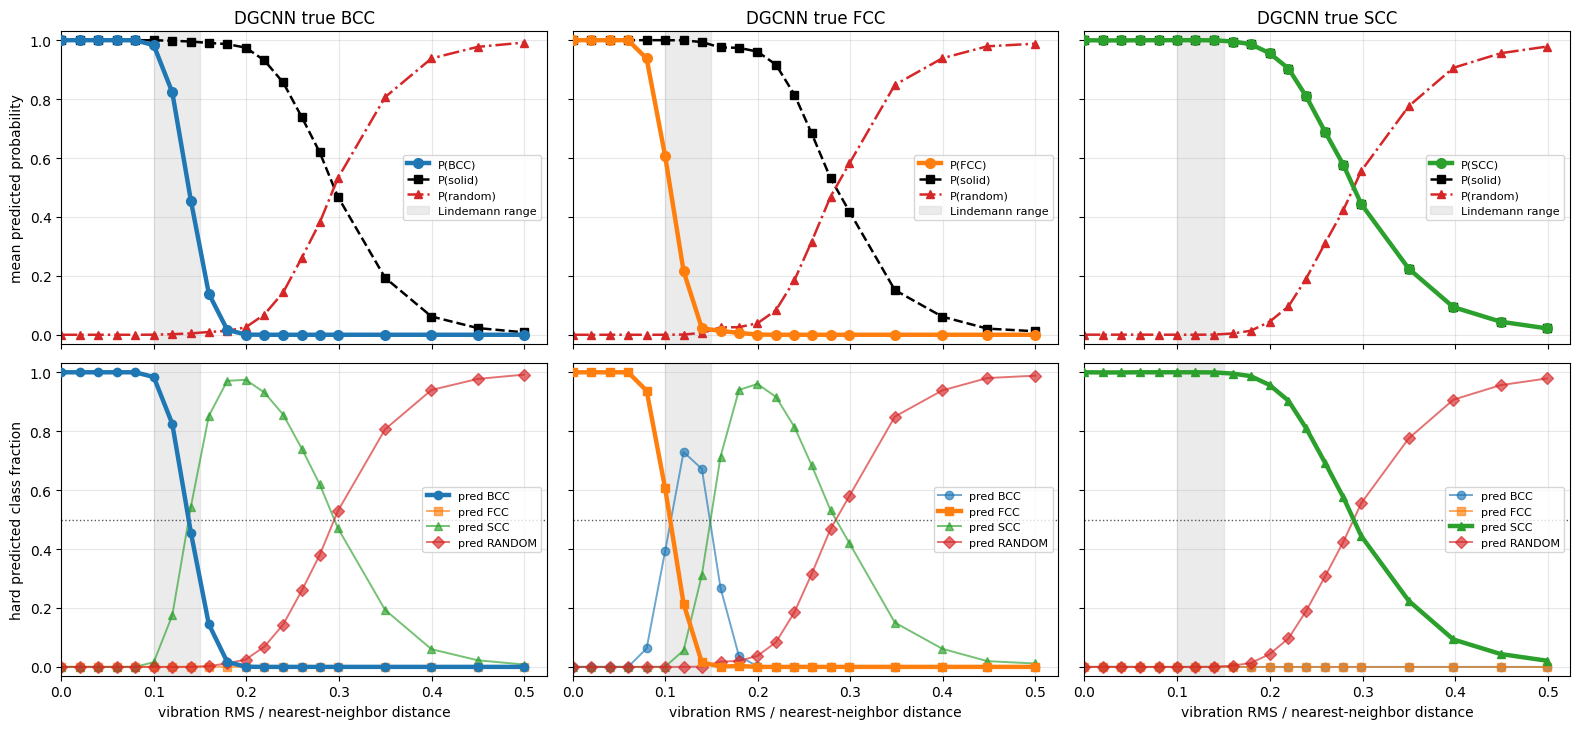

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

DGCNN_VIBRATION_RESULT_DIR = 'combined-vibration-results'
DGCNN_VIBRATION_LATTICES = ('bcc', 'fcc', 'scc')
DGCNN_RESULT_PREFIX = 'dgcnn'
DGCNN_CLASS_COLOR = {
    'bcc': 'tab:blue',
    'fcc': 'tab:orange',
    'scc': 'tab:green',
    'random': 'tab:red',
}
DGCNN_CLASS_MARKER = {
    'bcc': 'o',
    'fcc': 's',
    'scc': '^',
    'random': 'D',
}


def clean_dgcnn_class_name(value):
    if isinstance(value, bytes):
        return value.decode('utf-8').lower()
    return str(value).lower()


def dgcnn_prediction_fractions_from_counts(pred_class_counts):
    counts = pred_class_counts.astype(np.float64)
    totals = counts.sum(axis=1, keepdims=True)
    return np.divide(counts, totals, out=np.zeros_like(counts), where=totals > 0)


def plot_dgcnn_vibration_probability_and_confusion_curves(
    lattices=DGCNN_VIBRATION_LATTICES,
    result_dir=DGCNN_VIBRATION_RESULT_DIR,
    result_prefix=DGCNN_RESULT_PREFIX,
):
    fig, axes = plt.subplots(
        2,
        len(lattices),
        figsize=(5.3 * len(lattices), 7.4),
        sharex='col',
        sharey='row',
    )
    if len(lattices) == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, lattice in enumerate(lattices):
        ax_prob = axes[0, col]
        ax_frac = axes[1, col]
        path = os.path.join(result_dir, f'{result_prefix}-{lattice}-vibration-sweep.npz')

        if not os.path.exists(path):
            for ax in (ax_prob, ax_frac):
                ax.set_title(f'DGCNN true {lattice.upper()} missing')
                ax.text(
                    0.5,
                    0.5,
                    f'Missing {path}\nRun dgcnn-vibration-testing.py first',
                    ha='center',
                    va='center',
                    transform=ax.transAxes,
                )
                ax.set_axis_off()
            continue

        with np.load(path) as data:
            vibration_rms = data['measured_lindemann_mean']
            p_lattice = data['lattice_prob_mean']
            p_solid = data['solid_prob_mean']
            p_random = 1.0 - p_solid
            class_names = [clean_dgcnn_class_name(name) for name in data['class_names']]
            pred_fractions = dgcnn_prediction_fractions_from_counts(data['pred_class_counts'])

        ax_prob.plot(
            vibration_rms,
            p_lattice,
            'o-',
            color=DGCNN_CLASS_COLOR.get(lattice, 'tab:blue'),
            linewidth=3.2,
            markersize=7,
            zorder=5,
            label=f'P({lattice.upper()})',
        )
        ax_prob.plot(vibration_rms, p_solid, 's--', color='black', linewidth=1.8, label='P(solid)')
        ax_prob.plot(vibration_rms, p_random, '^-.', color=DGCNN_CLASS_COLOR['random'], linewidth=1.8, label='P(random)')
        ax_prob.axvspan(0.10, 0.15, color='0.85', alpha=0.5, label='Lindemann range')
        ax_prob.set_title(f'DGCNN true {lattice.upper()}')
        ax_prob.set_ylim(-0.03, 1.03)
        ax_prob.grid(True, alpha=0.3)
        ax_prob.legend(fontsize=8)

        for class_idx, class_name in enumerate(class_names):
            same_class = class_name == lattice
            line_width = 3.2 if same_class else 1.4
            line_alpha = 1.0 if same_class else 0.65
            z_order = 5 if same_class else 2
            ax_frac.plot(
                vibration_rms,
                pred_fractions[:, class_idx],
                marker=DGCNN_CLASS_MARKER.get(class_name, 'o'),
                linestyle='-',
                color=DGCNN_CLASS_COLOR.get(class_name, None),
                linewidth=line_width,
                alpha=line_alpha,
                zorder=z_order,
                label=f'pred {class_name.upper()}',
            )
        ax_frac.axvspan(0.10, 0.15, color='0.85', alpha=0.5)
        ax_frac.axhline(0.5, color='0.35', linestyle=':', linewidth=1)
        ax_frac.set_xlabel('vibration RMS / nearest-neighbor distance')
        ax_frac.set_xlim(left=0.0)
        ax_frac.set_ylim(-0.03, 1.03)
        ax_frac.grid(True, alpha=0.3)
        ax_frac.legend(fontsize=8)

    axes[0, 0].set_ylabel('mean predicted probability')
    axes[1, 0].set_ylabel('hard predicted class fraction')
    fig.tight_layout()
    return fig, axes


fig, axes = plot_dgcnn_vibration_probability_and_confusion_curves()
fig.savefig(
    os.path.join(DGCNN_VIBRATION_RESULT_DIR, 'dgcnn-vibration-probability-and-confusion-curves.png'),
    dpi=200,
    bbox_inches='tight',
)


In [33]:
  DGCNN_RESULT_DIR = "combined-vibration-results"
  DGCNN_LATTICES = ["bcc", "fcc", "scc"]

  for lattice in DGCNN_LATTICES:
      path = f"{DGCNN_RESULT_DIR}/dgcnn-{lattice}-vibration-sweep.npz"
      data = np.load(path)

      counts = data["pred_class_counts"]
      fractions = counts / counts.sum(axis=1, keepdims=True)

      print("=" * 70)
      print(f"True lattice: {lattice.upper()}")
      print("Classes:", data["class_names"])
      print("Factors:", data["factors"])
      print("Measured L:", np.round(data["measured_lindemann_mean"], 4))
      print()
      print("Counts [bcc, fcc, scc, random]:")
      print(counts)
      print()
      print("Fractions [bcc, fcc, scc, random]:")
      print(np.round(fractions, 4))
      print()


True lattice: BCC
Classes: ['bcc' 'fcc' 'scc' 'random']
Factors: [0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26
 0.28 0.3  0.35 0.4  0.45 0.5 ]
Measured L: [0.     0.02   0.0399 0.0599 0.0798 0.0999 0.1199 0.14   0.1593 0.1792
 0.1992 0.2193 0.2396 0.2599 0.2791 0.2987 0.3497 0.3997 0.4496 0.4994]

Counts [bcc, fcc, scc, random]:
[[2000    0    0    0]
 [2000    0    0    0]
 [2000    0    0    0]
 [2000    0    0    0]
 [2000    0    0    0]
 [1968    0   32    0]
 [1650    0  350    0]
 [ 911    1 1088    0]
 [ 290    2 1703    5]
 [  34    0 1942   24]
 [   1    0 1949   50]
 [   0    0 1863  137]
 [   0    0 1713  287]
 [   0    0 1480  520]
 [   0    0 1239  761]
 [   0    0  942 1058]
 [   0    0  387 1613]
 [   0    0  120 1880]
 [   0    0   45 1955]
 [   0    0   16 1984]]

Fractions [bcc, fcc, scc, random]:
[[1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e

In [35]:
%run rdf-vibration-study.py \
    --lattices bcc fcc scc \
    --cells 6 \
    --n-samples 8 \
    --r-max-over-nn 3.0 \
    --n-bins 240

bcc factor 0.0 measured_L 0.0 first_peak_height 38.7195987114461 first_peak_fwhm 0.025000000000000022 first_shell_coordination 7.99989712463355 time 0.08854269981384277
bcc factor 0.02 measured_L 0.020265097198482213 first_peak_height 10.954307766237392 first_peak_fwhm 0.0625 first_shell_coordination 7.999606452846495 time 0.09222173690795898
bcc factor 0.04 measured_L 0.03998789875706123 first_peak_height 6.016425064358411 first_peak_fwhm 0.08750000000000013 first_shell_coordination 7.857825536930462 time 0.09088945388793945
bcc factor 0.06 measured_L 0.05949987352469475 first_peak_height 3.9314968558981693 first_peak_fwhm 0.13750000000000007 first_shell_coordination 7.501058248457829 time 0.09654521942138672
bcc factor 0.08 measured_L 0.07899368409037487 first_peak_height 3.1331359165704185 first_peak_fwhm 0.275 first_shell_coordination 7.1926117095177835 time 0.08963346481323242
bcc factor 0.1 measured_L 0.10118729417541147 first_peak_height 2.7252726812960835 first_peak_fwhm 0.3000

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RDF_RESULT_DIR = Path("rdf-vibration-results")
PAPER_FIGURE_DIR = Path("paper-figures")
PAPER_FIGURE_DIR.mkdir(exist_ok=True)

LATTICES = ["bcc", "fcc", "scc"]
PLOT_FACTORS = [0.00, 0.10, 0.20, 0.30]
COLORS = {"bcc": "tab:blue", "fcc": "tab:green", "scc": "tab:red"}
DISPLAY_LABELS = {"bcc": "BCC", "fcc": "FCC", "scc": "SC"}
FIRST_SHELL_CUTOFF_OVER_NN = {
    "bcc": 0.5 * (1.0 + 2.0 / np.sqrt(3.0)),
    "fcc": 0.5 * (1.0 + np.sqrt(2.0)),
    "scc": 0.5 * (1.0 + np.sqrt(2.0)),
}

FIG5_PATH = PAPER_FIGURE_DIR / "rdf-gr-curves.png"
FIG6_PATH = PAPER_FIGURE_DIR / "rdf-first-peak-summary.png"

# FIG. 5: radial distribution functions g(r) at selected vibration amplitudes.
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.2), sharey=True)

for ax, lattice in zip(axes, LATTICES):
    data = np.load(RDF_RESULT_DIR / f"rdf-{lattice}-vibration-sweep.npz")

    factors = data["factors"]
    measured_L = data["measured_lindemann_mean"]
    r = data["r_over_nn"]
    gr = data["gr"]

    for target in PLOT_FACTORS:
        idx = np.argmin(np.abs(factors - target))
        ax.plot(r, gr[idx], linewidth=1.8, label=f"L={measured_L[idx]:.2f}")

    ax.axvline(1.0, color="black", linestyle=":", linewidth=1.0, label=r"$r_{nn}^{0}$")
    ax.axvline(
        FIRST_SHELL_CUTOFF_OVER_NN[lattice],
        color="0.35",
        linestyle="--",
        linewidth=1.0,
        label=r"$r_{cut}$",
    )
    ax.set_title(DISPLAY_LABELS.get(lattice, lattice.upper()))
    ax.set_xlabel(r"$r / r_{nn}^{0}$")
    ax.set_xlim(0.0, 3.0)
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"$g(r)$")
axes[-1].legend(title="Measured", fontsize=8, title_fontsize=8)
fig.tight_layout()
fig.savefig(FIG5_PATH, dpi=300, bbox_inches="tight")
print(f"saved {FIG5_PATH}")
plt.show()

# FIG. 6: RDF first-shell coordination and first-peak width.
fig, axes = plt.subplots(2, 1, figsize=(6.4, 5.4), sharex=True)

diagnostics = [
    ("first_shell_coordination", "First-shell coordination"),
    ("first_peak_fwhm", r"First peak FWHM / $r_{nn}^{0}$"),
]

for lattice in LATTICES:
    data = np.load(RDF_RESULT_DIR / f"rdf-{lattice}-vibration-sweep.npz")
    x = data["measured_lindemann_mean"]

    for ax, (key, _) in zip(axes, diagnostics):
        ax.plot(
            x,
            data[key],
            "o-",
            color=COLORS[lattice],
            linewidth=1.8,
            markersize=3.5,
            label=DISPLAY_LABELS.get(lattice, lattice.upper()),
        )

for ax, (_, ylabel) in zip(axes, diagnostics):
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Measured Lindemann ratio")
fig.tight_layout()
fig.savefig(FIG6_PATH, dpi=300, bbox_inches="tight")
print(f"saved {FIG6_PATH}")
plt.show()


## Voxelized lattice density visualization

Generate one lattice sample directly from the BCC/FCC/SC generator and visualize the `32 x 32 x 32` voxel-density image before and after Lindemann-type vibration. The plot uses a marching-cubes isosurface so the density peaks appear as continuous blobs rather than individual voxel points. Change `VOXEL_PLOT_LATTICE` to switch lattices.


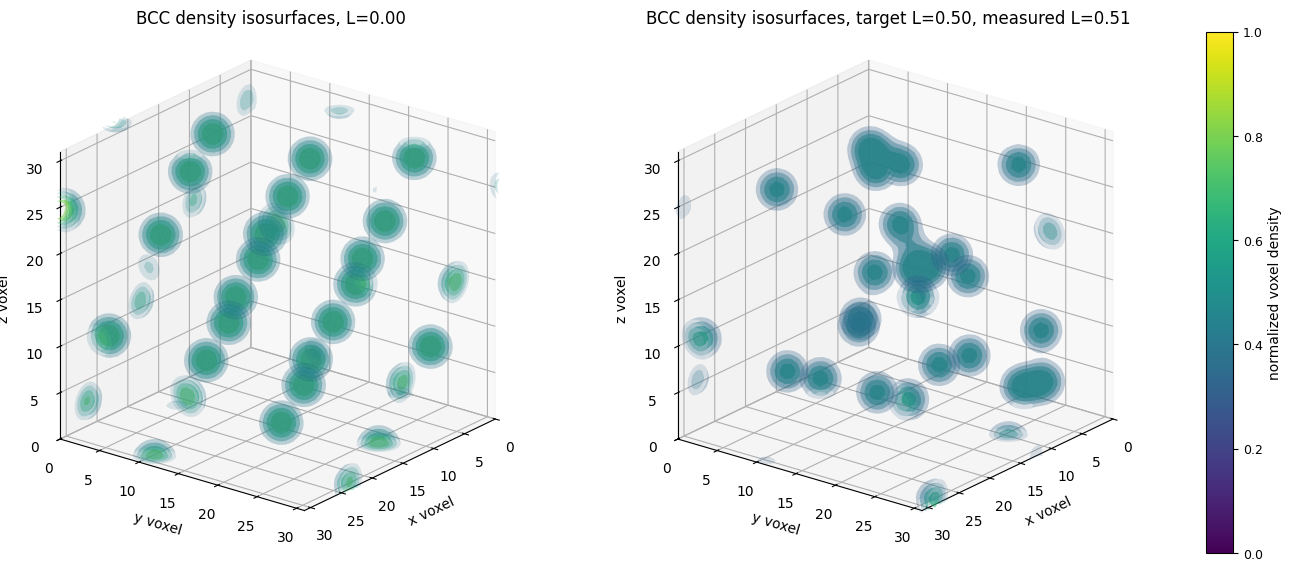

lattice: BCC
inner atoms: 25 buffer atoms: 131
clean nearest-neighbor distance: 0.36370784044265747
target Lindemann factor: 0.5 measured Lindemann ratio: 0.508891626604698
isosurface percentiles: [96.5, 98.0, 99.0, 99.6]
isosurface upsample: 2


In [68]:
import importlib.util
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

try:
    from skimage.measure import marching_cubes
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This visualization needs scikit-image for marching_cubes. "
        "Install it in the notebook environment with: pip install scikit-image"
    ) from exc

try:
    from scipy.ndimage import gaussian_filter, zoom
except ModuleNotFoundError:
    gaussian_filter = None
    zoom = None

VOXEL_PLOT_LATTICE = 'bcc'   # choose 'bcc', 'fcc', or 'scc'
VOXEL_PLOT_FACTOR = 0.50     # target RMS displacement / clean nearest-neighbor distance
VOXEL_PLOT_SEED = 26598
VOXEL_PLOT_NDIM = 32

# Isosurface controls for the paper-style continuous density view.
# Several nested density levels are shown so color represents voxel-density intensity.
VOXEL_PLOT_SURFACE_PERCENTILES = [96.5, 98.0, 99.0, 99.6]
VOXEL_PLOT_SURFACE_ALPHAS = [0.16, 0.24, 0.36, 0.58]
VOXEL_PLOT_SURFACE_CMAP = 'viridis'
VOXEL_PLOT_SURFACE_UPSAMPLE = 2       # use 1 to show the native 32^3 surface
VOXEL_PLOT_SURFACE_SIGMA = 0.45       # smoothing after upsampling; ignored if scipy is unavailable
VOXEL_PLOT_SAVE_PATH = 'paper-figures/voxel-density-bcc-L0-L050.png'
DISPLAY_LABELS = {'bcc': 'BCC', 'fcc': 'FCC', 'scc': 'SC'}


def import_lattice_generator(lattice):
    generator_path = Path(f'{lattice}-traindata.py')
    if not generator_path.exists():
        raise FileNotFoundError(f'Missing lattice generator: {generator_path}')
    spec = importlib.util.spec_from_file_location(f'{lattice}_generator', generator_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def unpack_lattice_output(out):
    if len(out) == 14:
        x, y, z, n, x_inner, y_inner, z_inner, n_inner, a, qw, qx, qy, qz, scaling = out
    else:
        x, y, z, n, x_inner, y_inner, z_inner, n_inner, a, th1, th2, th3, scaling = out
    return x, y, z, int(n), x_inner, y_inner, z_inner, int(n_inner), float(a), int(scaling)


def find_inner_buffer_indices(x_inner, y_inner, z_inner, n_inner, x_buffer, y_buffer, z_buffer, n_buffer, tol=1.0e-7):
    indices = np.full(n_inner, -1, dtype=np.int64)
    tol2 = tol * tol
    for i in range(n_inner):
        best = -1
        best_d2 = 1.0e30
        for j in range(n_buffer):
            dx = float(x_inner[i] - x_buffer[j])
            dy = float(y_inner[i] - y_buffer[j])
            dz = float(z_inner[i] - z_buffer[j])
            d2 = dx * dx + dy * dy + dz * dz
            if d2 < best_d2:
                best_d2 = d2
                best = j
        if best_d2 <= tol2:
            indices[i] = best
    return indices


def nearest_neighbor_reference(x_inner, y_inner, z_inner, n_inner, x_buffer, y_buffer, z_buffer, n_buffer, inner_indices):
    distances = np.zeros(n_inner, dtype=np.float32)
    for i in range(n_inner):
        skip_idx = int(inner_indices[i])
        best = 1.0e30
        for j in range(n_buffer):
            if j == skip_idx:
                continue
            dx = float(x_inner[i] - x_buffer[j])
            dy = float(y_inner[i] - y_buffer[j])
            dz = float(z_inner[i] - z_buffer[j])
            d2 = dx * dx + dy * dy + dz * dz
            if d2 > 1.0e-14 and d2 < best:
                best = d2
        distances[i] = np.sqrt(best)
    return float(distances.mean())


def apply_lindemann_vibration(x, y, z, n, inner_indices, d0, factor, rng):
    sigma = factor * d0 / np.sqrt(3.0)
    displacement = rng.normal(0.0, sigma, size=(n, 3)).astype(np.float32)

    xd = np.array(x, copy=True)
    yd = np.array(y, copy=True)
    zd = np.array(z, copy=True)
    xd[:n] = x[:n] + displacement[:, 0]
    yd[:n] = y[:n] + displacement[:, 1]
    zd[:n] = z[:n] + displacement[:, 2]

    valid = inner_indices[inner_indices >= 0]
    rms = np.sqrt(np.mean(np.sum(displacement[valid] ** 2, axis=1)))
    measured_l = float(rms / d0) if d0 > 0.0 else np.nan
    return xd, yd, zd, measured_l


def prepare_isosurface_volume(image):
    voxel = np.squeeze(image).astype(np.float32)
    scale = 1.0

    if VOXEL_PLOT_SURFACE_UPSAMPLE > 1 and zoom is not None:
        scale = float(VOXEL_PLOT_SURFACE_UPSAMPLE)
        voxel = zoom(voxel, VOXEL_PLOT_SURFACE_UPSAMPLE, order=2)

    if VOXEL_PLOT_SURFACE_SIGMA > 0.0 and gaussian_filter is not None:
        voxel = gaussian_filter(voxel, sigma=VOXEL_PLOT_SURFACE_SIGMA)

    voxel -= voxel.min()
    max_value = voxel.max()
    if max_value > 0.0:
        voxel /= max_value
    return voxel, scale


def plot_voxel_isosurfaces(ax, image, title):
    voxel, scale = prepare_isosurface_volume(image)
    cmap = plt.get_cmap(VOXEL_PLOT_SURFACE_CMAP)
    norm = plt.Normalize(vmin=0.0, vmax=1.0)
    vmin = float(voxel.min())
    vmax = float(voxel.max())
    meshes = []

    for surface_index, percentile in enumerate(VOXEL_PLOT_SURFACE_PERCENTILES):
        level = float(np.percentile(voxel, percentile))
        if not (vmin < level < vmax):
            continue

        verts, faces, normals, values = marching_cubes(voxel, level=level)
        verts = verts / scale

        alpha = VOXEL_PLOT_SURFACE_ALPHAS[min(surface_index, len(VOXEL_PLOT_SURFACE_ALPHAS) - 1)]
        face_color = cmap(norm(level))
        mesh = Poly3DCollection(verts[faces], alpha=alpha)
        mesh.set_facecolor(face_color)
        mesh.set_edgecolor('none')
        ax.add_collection3d(mesh)
        meshes.append(mesh)

    if not meshes:
        raise RuntimeError('No isosurfaces were generated. Lower VOXEL_PLOT_SURFACE_PERCENTILES.')

    ax.set_title(title)
    ax.set_xlabel('x voxel')
    ax.set_ylabel('y voxel')
    ax.set_zlabel('z voxel')
    ax.set_xlim(0, VOXEL_PLOT_NDIM - 1)
    ax.set_ylim(0, VOXEL_PLOT_NDIM - 1)
    ax.set_zlim(0, VOXEL_PLOT_NDIM - 1)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=38)
    try:
        ax.set_proj_type('ortho')
    except AttributeError:
        pass

    return plt.cm.ScalarMappable(norm=norm, cmap=cmap)


generator = import_lattice_generator(VOXEL_PLOT_LATTICE)
np.random.seed(VOXEL_PLOT_SEED)
generator.seed_numba_rng(VOXEL_PLOT_SEED)
rng = np.random.default_rng(VOXEL_PLOT_SEED + 1)

out = generator.true_lattice_with_metadata(generator.NMAX)
x, y, z, n, x_inner, y_inner, z_inner, n_inner, a, scaling = unpack_lattice_output(out)
inner_indices = find_inner_buffer_indices(x_inner, y_inner, z_inner, n_inner, x, y, z, n)
d0 = nearest_neighbor_reference(x_inner, y_inner, z_inner, n_inner, x, y, z, n, inner_indices)

image_clean = generator.image_create(VOXEL_PLOT_NDIM, n, x, y, z)
xd, yd, zd, measured_l = apply_lindemann_vibration(
    x, y, z, n, inner_indices, d0, VOXEL_PLOT_FACTOR, rng,
)
image_vibrated = generator.image_create(VOXEL_PLOT_NDIM, n, xd, yd, zd)

fig = plt.figure(figsize=(13.2, 5.6), constrained_layout=True)
grid = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 0.045], wspace=0.04)
ax0 = fig.add_subplot(grid[0, 0], projection='3d')
ax1 = fig.add_subplot(grid[0, 1], projection='3d')
cax = fig.add_subplot(grid[0, 2])

mappable = plot_voxel_isosurfaces(
    ax0,
    image_clean,
    f'{DISPLAY_LABELS.get(VOXEL_PLOT_LATTICE, VOXEL_PLOT_LATTICE.upper())} density isosurfaces, L=0.00',
)
plot_voxel_isosurfaces(
    ax1,
    image_vibrated,
    f'{DISPLAY_LABELS.get(VOXEL_PLOT_LATTICE, VOXEL_PLOT_LATTICE.upper())} density isosurfaces, target L={VOXEL_PLOT_FACTOR:.2f}, measured L={measured_l:.2f}',
)
cbar = fig.colorbar(mappable, cax=cax, label='normalized voxel density')
cbar.ax.tick_params(labelsize=9)

fig.suptitle('', y=0.98)
if VOXEL_PLOT_SAVE_PATH:
    fig.savefig(VOXEL_PLOT_SAVE_PATH, dpi=220, bbox_inches='tight')
plt.show()

print('lattice:', DISPLAY_LABELS.get(VOXEL_PLOT_LATTICE, VOXEL_PLOT_LATTICE.upper()))
print('inner atoms:', n_inner, 'buffer atoms:', n)
print('clean nearest-neighbor distance:', d0)
print('target Lindemann factor:', VOXEL_PLOT_FACTOR, 'measured Lindemann ratio:', measured_l)
print('isosurface percentiles:', VOXEL_PLOT_SURFACE_PERCENTILES)
print('isosurface upsample:', VOXEL_PLOT_SURFACE_UPSAMPLE if zoom is not None else 1)


In [49]:
pip install scikit-image

INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 28.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.
